# Problem Statment

**Objective:** Develop a predictive model that accurately estimates the prices of used cars in the Indian market based on various attributes like brand, model, manufacturing year, kilometers driven, fuel type, and more. The model will help Cars4U, a start-up, in understanding the factors that influence used car prices and in devising a differential pricing strategy to maximize profitability and competitiveness in the market.

**Goal:** To build a linear regression model that predicts the price of used cars, allowing Cars4U to make informed decisions on buying and selling pre-owned vehicles, ensuring they are priced competitively and profitably without falling below market value. The model will also provide insights and recommendations for better pricing strategies, helping Cars4U navigate the uncertainties of the used car market.

•	DATA DICTIONARY :
1.	S.No.: Serial number
2.	Name: Name of the car which includes brand name and model name
3.	Location: Location in which the car is being sold or is available for purchase (cities)
4.	Year: Manufacturing year of the car
5.	Kilometres_driven: The total kilometers driven in the car by the previous owner(s) in km
6.	Fuel_Type: The type of fuel used by the car (Petrol, Diesel, Electric, CNG, LPG)
7.	Transmission: The type of transmission used by the car (Automatic/Manual)
8.	Owner: Type of ownership
9.	Mileage: The standard mileage offered by the car company in kmpl or km/kg
10.	Engine: The displacement volume of the engine in CC
11.	Power: The maximum power of the engine in bhp
12.	Seats: The number of seats in the car
13.	New_Price: The price of a new car of the same model in INR Lakhs (1 Lakh INR = 100,000 INR)
14.	Price: The price of the used car in INR Lakhs


## Importing necessary libraries

In [370]:
# this will help in making the Python code more structured automatically (good coding practice)
# %load_ext nb_black

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to split the data into train and test
from sklearn.model_selection import train_test_split

# to build linear regression_model
from sklearn.linear_model import LinearRegression

# to check model performance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# to suppress warnings
import warnings

warnings.filterwarnings("ignore")

## A. Read and Inspect Dataset
- **Task:** Read the ‘used_cars_data.csv’ dataset, check the dimensions, and print the first 10 rows.


## Loading the dataset

In [371]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [372]:
# Reading the data
dff = pd.read_csv('/content/drive/MyDrive/Dataset_used_cars_data.csv')

In [373]:
# copying data to another variable to avoid any changes to original data
data = dff.copy()

## Data Overview

### Displaying the first few rows of the dataset

In [374]:
data.head()

,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,5.51,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,16.06,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,11.27,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,53.14,17.74


### Checking the shape of the dataset

In [375]:
# checking shape of the data
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 7253 rows and 14 columns.


In [376]:
# Checking the dimensions of the dataset (rows and columns)
dimensions = data.shape
print(f"Dimensions of the dataset: {dimensions}")



Dimensions of the dataset: (7253, 14)


In [377]:
# Printing the first 10 rows of the dataset
print("First 10 rows of the dataset:")
print(data.head(10))

First 10 rows of the dataset:
   S.No.                                 Name    Location  Year  \
0      0               Maruti Wagon R LXI CNG      Mumbai  2010   
1      1     Hyundai Creta 1.6 CRDi SX Option        Pune  2015   
2      2                         Honda Jazz V     Chennai  2011   
3      3                    Maruti Ertiga VDI     Chennai  2012   
4      4      Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013   
5      5      Hyundai EON LPG Era Plus Option   Hyderabad  2012   
6      6               Nissan Micra Diesel XV      Jaipur  2013   
7      7    Toyota Innova Crysta 2.8 GX AT 8S      Mumbai  2016   
8      8  Volkswagen Vento Diesel Comfortline        Pune  2013   
9      9       Tata Indica Vista Quadrajet LS     Chennai  2012   

   Kilometers_Driven Fuel_Type Transmission Owner_Type     Mileage   Engine  \
0              72000       CNG       Manual      First  26.6 km/kg   998 CC   
1              41000    Diesel       Manual      First  19.67 kmpl  1582 C

## B. Data Types and Duplicates
- **Task:** Check data types and duplicate values in the data-frame. Treat the duplicates if any, with an explanation of your approach.

In [378]:
# Check the data types of each column in the DataFrame
print("Data types of each column:")
data.info()

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.No.              7253 non-null   int64  
 1   Name               7253 non-null   object 
 2   Location           7253 non-null   object 
 3   Year               7253 non-null   int64  
 4   Kilometers_Driven  7253 non-null   int64  
 5   Fuel_Type          7253 non-null   object 
 6   Transmission       7253 non-null   object 
 7   Owner_Type         7253 non-null   object 
 8   Mileage            7251 non-null   object 
 9   Engine             7207 non-null   object 
 10  Power              7078 non-null   object 
 11  Seats              7200 non-null   float64
 12  New_Price          7253 non-null   float64
 13  Price              6019 non-null   float64
dtypes: float64(3), int64(3), object(8)
memory usage: 793.4+ KB


In [379]:
# Check for duplicate values in the DataFrame
num_duplicates = data.duplicated().sum()
print(f"\nNumber of duplicate rows in the dataset: {num_duplicates}")


Number of duplicate rows in the dataset: 0


## C. Mileage and Fuel Type Relationship
- **Task:** Observe if there’s any relationship between the units given in the mileage column and the Fuel_Type. Split the mileage column into numeric values and units.

In [380]:
# Displaying the first few rows of the dataset to understand its structure
print("Sample data from 'Mileage' column:")
print(data[['Mileage', 'Fuel_Type']].head())

Sample data from 'Mileage' column:
      Mileage Fuel_Type
0  26.6 km/kg       CNG
1  19.67 kmpl    Diesel
2   18.2 kmpl    Petrol
3  20.77 kmpl    Diesel
4   15.2 kmpl    Diesel


In [381]:
# Split the 'Mileage' column into numeric values and units
data[['Mileage_Value', 'Mileage_Unit']] = data['Mileage'].str.extract(r'(\d+\.?\d*)\s*(\S+)')


In [382]:
# Convert Mileage_Value to numeric for further analysis
data['Mileage_Value'] = pd.to_numeric(data['Mileage_Value'], errors='coerce')


In [383]:
# Displaying the first few rows after splitting
print("\nData after splitting 'Mileage' into 'Mileage_Value' and 'Mileage_Unit':")
print(data[['Mileage', 'Mileage_Value', 'Mileage_Unit', 'Fuel_Type']].head(10))


Data after splitting 'Mileage' into 'Mileage_Value' and 'Mileage_Unit':
      Mileage  Mileage_Value Mileage_Unit Fuel_Type
0  26.6 km/kg          26.60        km/kg       CNG
1  19.67 kmpl          19.67         kmpl    Diesel
2   18.2 kmpl          18.20         kmpl    Petrol
3  20.77 kmpl          20.77         kmpl    Diesel
4   15.2 kmpl          15.20         kmpl    Diesel
5  21.1 km/kg          21.10        km/kg       LPG
6  23.08 kmpl          23.08         kmpl    Diesel
7  11.36 kmpl          11.36         kmpl    Diesel
8  20.54 kmpl          20.54         kmpl    Diesel
9   22.3 kmpl          22.30         kmpl    Diesel


In [384]:
# Observing relationship between Mileage units and Fuel_Type
print("\nRelationship between Mileage units and Fuel_Type:")
mileage_fuel_relationship = data.groupby(['Fuel_Type', 'Mileage_Unit']).size().reset_index(name='Count')
print(mileage_fuel_relationship)


Relationship between Mileage units and Fuel_Type:
  Fuel_Type Mileage_Unit  Count
0       CNG        km/kg     62
1    Diesel         kmpl   3852
2       LPG        km/kg     12
3    Petrol         kmpl   3325


**Observation:** Here we can observe that CNG and LPG have km/kg unints , on the ohter hand Diesel and Petrol have kmpl unit.

## D. Extract Numeric Values
- **Task:** Extract numeric values from ‘Engine’, ‘Power’, and ‘New_Price’. Check for variation in their units and drop the units if necessary.


In [385]:
# Sample display of the columns to understand their content
print("Sample data from 'Engine', 'Power', and 'New_Price' columns:")
print(data[['Engine', 'Power', 'New_Price']].head())


Sample data from 'Engine', 'Power', and 'New_Price' columns:
    Engine      Power  New_Price
0   998 CC  58.16 bhp       5.51
1  1582 CC  126.2 bhp      16.06
2  1199 CC   88.7 bhp       8.61
3  1248 CC  88.76 bhp      11.27
4  1968 CC  140.8 bhp      53.14


In [386]:
# Extract numeric values from 'Engine', 'Power', and 'New_Price' columns
# Using str.extract() to separate numeric values and units

# Extract numeric values and units for 'Engine'
data[['Engine_Value', 'Engine_Unit']] = data['Engine'].str.extract(r'(\d+\.?\d*)\s*(\w*)')

# Extract numeric values and units for 'Power'
data[['Power_Value', 'Power_Unit']] = data['Power'].str.extract(r'(\d+\.?\d*)\s*(\w*)')



# Convert extracted numeric values to float for further analysis
data['Engine_Value'] = pd.to_numeric(data['Engine_Value'], errors='coerce')
data['Power_Value'] = pd.to_numeric(data['Power_Value'], errors='coerce')

We have not extracted numeric value from New_Price because it is itself is a numeric value.

In [387]:
# Display first few rows after extracting numeric values
print("\nData after extracting numeric values and units:")
print(data[['Engine', 'Engine_Value', 'Engine_Unit', 'Power', 'Power_Value', 'Power_Unit', 'New_Price']].head())



Data after extracting numeric values and units:
    Engine  Engine_Value Engine_Unit      Power  Power_Value Power_Unit  \
0   998 CC         998.0          CC  58.16 bhp        58.16        bhp   
1  1582 CC        1582.0          CC  126.2 bhp       126.20        bhp   
2  1199 CC        1199.0          CC   88.7 bhp        88.70        bhp   
3  1248 CC        1248.0          CC  88.76 bhp        88.76        bhp   
4  1968 CC        1968.0          CC  140.8 bhp       140.80        bhp   

   New_Price  
0       5.51  
1      16.06  
2       8.61  
3      11.27  
4      53.14  


In [388]:
 # Checking for variation in units
print("\nUnique units in 'Engine_Unit':", data['Engine_Unit'].unique())
print("Unique units in 'Power_Unit':", data['Power_Unit'].unique())



Unique units in 'Engine_Unit': ['CC' nan]
Unique units in 'Power_Unit': ['bhp' nan]


In [389]:
# Dropping the units columns if units are consistent and not needed for further analysis
# (Assumption: We are mainly interested in numeric values for modeling)
data.drop(['Engine_Unit', 'Power_Unit'], axis=1, inplace=True)

# Display the updated DataFrame
print("\nUpdated DataFrame after dropping units columns:")
print(data.head())


Updated DataFrame after dropping units columns:
   S.No.                              Name    Location  Year  \
0      0            Maruti Wagon R LXI CNG      Mumbai  2010   
1      1  Hyundai Creta 1.6 CRDi SX Option        Pune  2015   
2      2                      Honda Jazz V     Chennai  2011   
3      3                 Maruti Ertiga VDI     Chennai  2012   
4      4   Audi A4 New 2.0 TDI Multitronic  Coimbatore  2013   

   Kilometers_Driven Fuel_Type Transmission Owner_Type     Mileage   Engine  \
0              72000       CNG       Manual      First  26.6 km/kg   998 CC   
1              41000    Diesel       Manual      First  19.67 kmpl  1582 CC   
2              46000    Petrol       Manual      First   18.2 kmpl  1199 CC   
3              87000    Diesel       Manual      First  20.77 kmpl  1248 CC   
4              40670    Diesel    Automatic     Second   15.2 kmpl  1968 CC   

       Power  Seats  New_Price  Price  Mileage_Value Mileage_Unit  \
0  58.16 bhp    5.0   

## E. Extract Car Brand and Model
- **Task:** Extract the Car Brand Name and Model Name from the ‘Name’ column.

In [390]:
# Displaying the first few rows to understand the structure of the 'Name' column
print("Sample data from 'Name' column:")
print(data['Name'].head())

Sample data from 'Name' column:
0              Maruti Wagon R LXI CNG
1    Hyundai Creta 1.6 CRDi SX Option
2                        Honda Jazz V
3                   Maruti Ertiga VDI
4     Audi A4 New 2.0 TDI Multitronic
Name: Name, dtype: object


In [391]:
# Splitting the 'Name' column to extract only the first word as 'Brand_Name'
# and the rest of the words as 'Model_Name'
data['Brand_Name'] = data['Name'].str.split(' ', n=1).str[0]
data['Model_Name'] = data['Name'].str.split(' ', n=1).str[1]


In [392]:
# Displaying the updated DataFrame with the new 'Brand_Name' and 'Model_Name' columns
print("\nData after extracting 'Brand_Name' and 'Model_Name':")
print(data[['Name', 'Brand_Name', 'Model_Name']].head())


Data after extracting 'Brand_Name' and 'Model_Name':
                               Name Brand_Name                  Model_Name
0            Maruti Wagon R LXI CNG     Maruti             Wagon R LXI CNG
1  Hyundai Creta 1.6 CRDi SX Option    Hyundai    Creta 1.6 CRDi SX Option
2                      Honda Jazz V      Honda                      Jazz V
3                 Maruti Ertiga VDI     Maruti                  Ertiga VDI
4   Audi A4 New 2.0 TDI Multitronic       Audi  A4 New 2.0 TDI Multitronic


In [393]:
data.drop(['Name'], axis=1, inplace=True)
# there is no need for Name column.

## F. Log Transformation
- **Task:** Create new variables by log transforming ‘Price’ and ‘Kilometers_Driven’ columns as ‘price_log’ and ‘kilometers_driven_log’.


In [394]:
# Applying log transformation to 'Price' and 'Kilometers_Driven' columns
# Creating new columns 'price_log' and 'kilometers_driven_log'
# Adding 1 to avoid taking log of zero (if applicable) - assuming Price and Kilometers_Driven are non-zero
data['price_log'] = np.log(data['Price'] + 1)
data['kilometers_driven_log'] = np.log(data['Kilometers_Driven'] + 1)

In [395]:
# Displaying the updated DataFrame with the new log-transformed columns
print("\nData after log transformation:")
print(data[['Price', 'Kilometers_Driven', 'price_log', 'kilometers_driven_log']].head())


Data after log transformation:
   Price  Kilometers_Driven  price_log  kilometers_driven_log
0   1.75              72000   1.011601              11.184435
1  12.50              41000   2.602690              10.621352
2   4.50              46000   1.704748              10.736418
3   6.00              87000   1.945910              11.373675
4  17.74              40670   2.930660              10.613271


## G. Drop Redundant Columns
- **Task:** Drop the redundant columns and print a 5-point summary of the data-frame. Share your observation.


In [396]:
# Dropping redundant columns
data = data.drop(['S.No.', 'Mileage', 'Engine', 'Power','Mileage_Unit'], axis=1)
df = data.copy()
# Print the 5-point summary of the cleaned DataFrame
print("Five-point summary of the cleaned data:")
print(df.describe().T)

Five-point summary of the cleaned data:
                        count          mean           std          min  \
Year                   7253.0   2013.365366      3.254421  1996.000000   
Kilometers_Driven      7253.0  58699.063146  84427.720583   171.000000   
Seats                  7200.0      5.279722      0.811660     0.000000   
New_Price              7253.0     21.307322     24.256314     3.910000   
Price                  6019.0      9.479468     11.187917     0.440000   
Mileage_Value          7251.0     18.141580      4.562197     0.000000   
Engine_Value           7207.0   1616.573470    595.285137    72.000000   
Power_Value            7078.0    112.765214     53.493553    34.200000   
price_log              6019.0      2.018429      0.748221     0.364643   
kilometers_driven_log  7253.0     10.761010      0.716276     5.147494   

                                25%           50%           75%           max  
Year                    2011.000000   2014.000000   2016.000000  

**Year:** The dataset has a wide range of manufacturing years, with a higher concentration of cars manufactured around 2013-2016.

**Kilometers Driven:** There is significant variation, with some cars having very high mileage, possibly indicating older or heavily used vehicles.
**Seats:** Most cars have the standard 5 seats, but there are a few larger vehicles.

**Price and New Price:** The cars range from budget to high-end luxury vehicles, with some possibly being luxury brands due to the high maximum prices.

**Mileage, Engine, and Power:**The dataset shows a variety of car types, from fuel-efficient, small-engine cars to high-powered luxury vehicles.

**Log-transformed values:** The log transformation of price and kilometers driven reduces skewness, making it easier to interpret and model these variables.

## H. Missing and Extreme Values
- **Task:** Check the missing values and extreme values in the dataset and impute them. (Do not impute missing values for price as it is our target column).


In [397]:
#  Check for missing values
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Seats              53
Price            1234
Mileage_Value       2
Engine_Value       46
Power_Value       175
price_log        1234
dtype: int64


In [398]:
#  Impute missing values (excluding 'Price' column)
# For numerical columns, we'll use median imputation as an example
for column in df.columns:
    if column not in ['Price'] and df[column].dtype in [np.int64, np.float64]:
        df[column].fillna(df[column].median(), inplace=True)

In [399]:
# check for the missing Values again after impute
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Price    1234
dtype: int64


In [400]:
#  Check for extreme values
numerical_columns = df.select_dtypes(include=[np.number]).columns
# Define a function to identify extreme values (outliers)
# Define a function to calculate and display outliers using IQR
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f'Number of Extreme Values in {column}: {outliers.shape[0]}')
    return outliers

# Check outliers for each numerical column
for col in numerical_columns:
    detect_outliers_iqr(data, col)


Number of Extreme Values in Year: 58
Number of Extreme Values in Kilometers_Driven: 258
Number of Extreme Values in Seats: 1153
Number of Extreme Values in New_Price: 1098
Number of Extreme Values in Price: 718
Number of Extreme Values in Mileage_Value: 99
Number of Extreme Values in Engine_Value: 65
Number of Extreme Values in Power_Value: 273
Number of Extreme Values in price_log: 168
Number of Extreme Values in kilometers_driven_log: 279


We are not treating outliers as they may have practical possibility of existance.

Let check the missing values in the dataframe

In [401]:
# Verify that missing and extreme values are handled
print("\nMissing values after imputation:")
print(df.isnull().sum())
print("\nSummary after imputation and outlier handling:")
print(df.describe())


Missing values after imputation:
Location                    0
Year                        0
Kilometers_Driven           0
Fuel_Type                   0
Transmission                0
Owner_Type                  0
Seats                       0
New_Price                   0
Price                    1234
Mileage_Value               0
Engine_Value                0
Power_Value                 0
Brand_Name                  0
Model_Name                  0
price_log                   0
kilometers_driven_log       0
dtype: int64

Summary after imputation and outlier handling:
              Year  Kilometers_Driven        Seats    New_Price        Price  \
count  7253.000000       7.253000e+03  7253.000000  7253.000000  6019.000000   
mean   2013.365366       5.869906e+04     5.277678    21.307322     9.479468   
std       3.254421       8.442772e+04     0.809039    24.256314    11.187917   
min    1996.000000       1.710000e+02     0.000000     3.910000     0.440000   
25%    2011.000000       

## I. Distribution of Non-Numeric Features
- **Task:** Check the distribution of non-numeric features (display the first 10 values if the number of categories/classes is more than 10).


In [402]:
# 1. Identify non-numeric features
non_numeric_features = df.select_dtypes(include=['object']).columns
# 2. Display the distribution of non-numeric features
# Loop through each non-numeric column and display distribution
for column in df.select_dtypes(include='object').columns:
    print(f"Distribution of {column}:\n")

    # Calculate the frequency of each category
    value_counts = df[column].value_counts()

    # Display the distribution
    if len(value_counts) > 10:
        print(value_counts.head(10))  # Show only the first 10 categories if more than 10
        print("...")  # Indicating that there are more categories not displayed
    else:
        print(value_counts)  # Show all categories if 10 or less

    print("\n" + "-"*50 + "\n")


Distribution of Location:

Location
Mumbai        949
Hyderabad     876
Coimbatore    772
Kochi         772
Pune          765
Delhi         660
Kolkata       654
Chennai       591
Jaipur        499
Bangalore     440
Name: count, dtype: int64
...

--------------------------------------------------

Distribution of Fuel_Type:

Fuel_Type
Diesel      3852
Petrol      3325
CNG           62
LPG           12
Electric       2
Name: count, dtype: int64

--------------------------------------------------

Distribution of Transmission:

Transmission
Manual       5204
Automatic    2049
Name: count, dtype: int64

--------------------------------------------------

Distribution of Owner_Type:

Owner_Type
First             5952
Second            1152
Third              137
Fourth & Above      12
Name: count, dtype: int64

--------------------------------------------------

Distribution of Brand_Name:

Brand_Name
Maruti           1444
Hyundai          1340
Honda             743
Toyota            507
M

## J. Average Price by Brand [1 Mark]
- **Task:** Share the average of used car prices by brand.

In [403]:
# Group by 'Brand_Name' and calculate the average price for each brand
average_price_by_brand = df.groupby('Brand_Name')['Price'].mean().reset_index()

# Rename the columns for clarity
average_price_by_brand.columns = ['Brand_Name', 'Average_Price']

# Sort the results by average price in descending order
average_price_by_brand = average_price_by_brand.sort_values(by='Average_Price', ascending=False)

# Display the average price by brand
print("Average price of used cars by brand:")
print(average_price_by_brand)

Average price of used cars by brand:
       Brand_Name  Average_Price
16    Lamborghini     120.000000
3         Bentley      59.000000
25        Porsche      48.348333
17           Land      39.259500
14         Jaguar      37.632250
21           Mini      26.896923
20  Mercedes-Benz      26.809874
1            Audi      25.537712
2             BMW      25.243146
13          Isuzu      20.000000
32          Volvo      18.802857
15           Jeep      18.718667
12          ISUZU      12.045000
30         Toyota      11.580024
22     Mitsubishi      11.058889
7           Force       9.333333
18       Mahindra       8.045919
27          Skoda       7.559075
8            Ford       6.889400
26        Renault       5.799034
10          Honda       5.411743
11        Hyundai       5.343433
31     Volkswagen       5.307270
23         Nissan       4.738352
19         Maruti       4.517267
29           Tata       3.562849
6            Fiat       3.269286
5          Datsun       3.049231
4     

## <a name='link2'>Exploratory Data Analysis (EDA) Summary</a>


**The below functions need to be defined to carry out the Exploratory Data Analysis.**

In [404]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [405]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Univariate Analysis

In [406]:
# creating a copy of the dataframe
df1 = df.copy()

#### `Price`

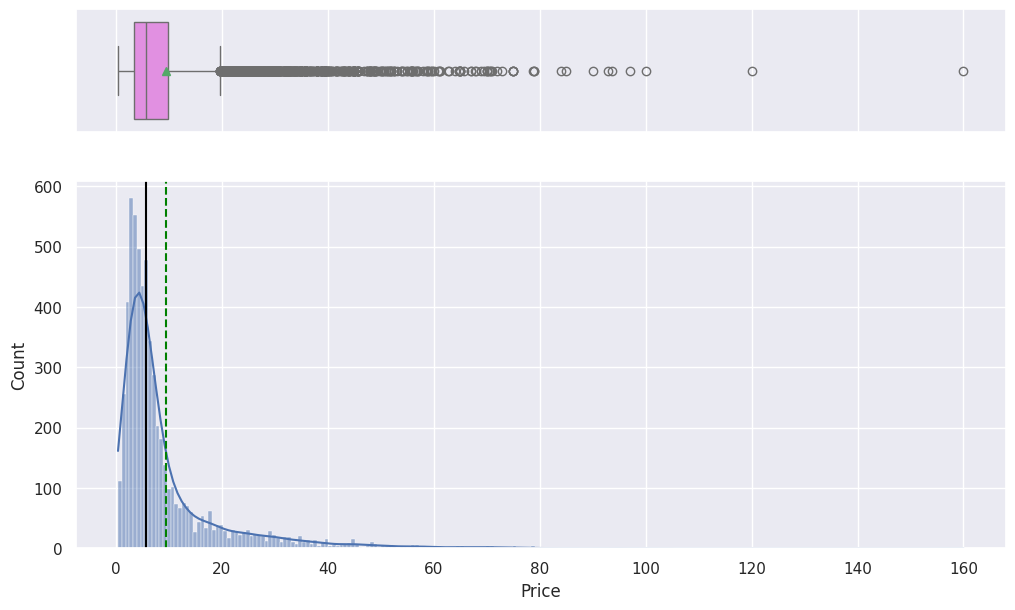

In [407]:
histogram_boxplot(df1, "Price", kde=True)

**Observations**

* This is a highly skewed distribution.


#### `New_Price`

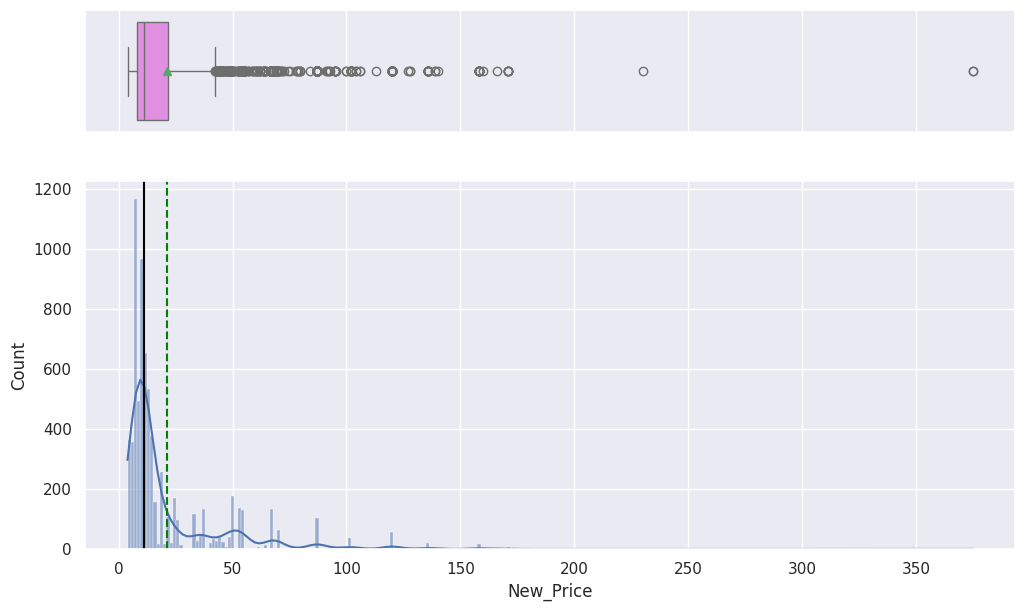

In [408]:
histogram_boxplot(df1, "New_Price", kde=True)

**Observations**

* This is another highly skewed distribution.


#### `Brand`

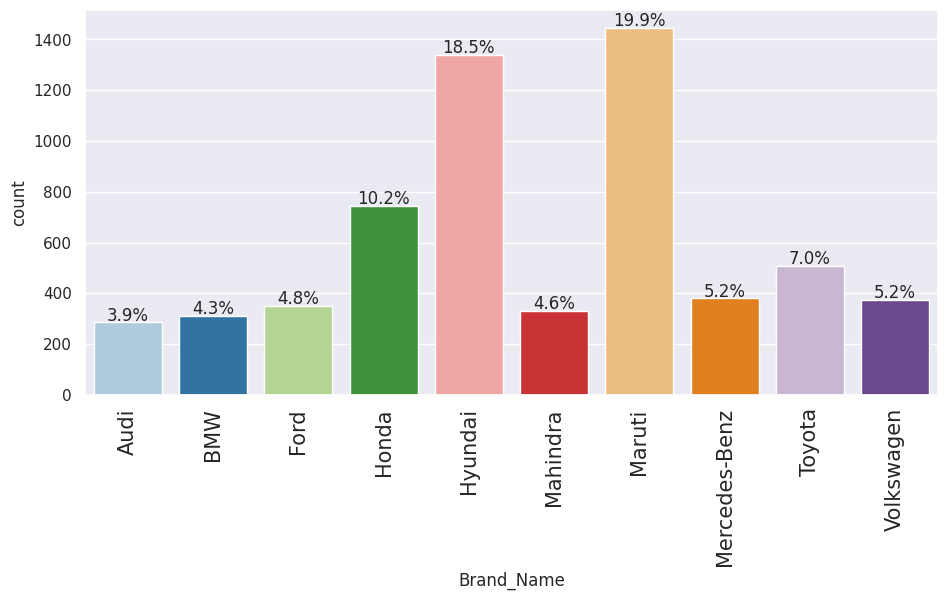

In [409]:
labeled_barplot(df1, "Brand_Name", perc=True, n=10)

* Most of the cars in the data belong to Maruti or Hyundai. The price of used cars is lower for budget brands like Porsche, Bentley, Lamborghini, etc. The price of used cars is higher for premium brands like Maruti, Tata, Fiat, etc.

#### `Location`

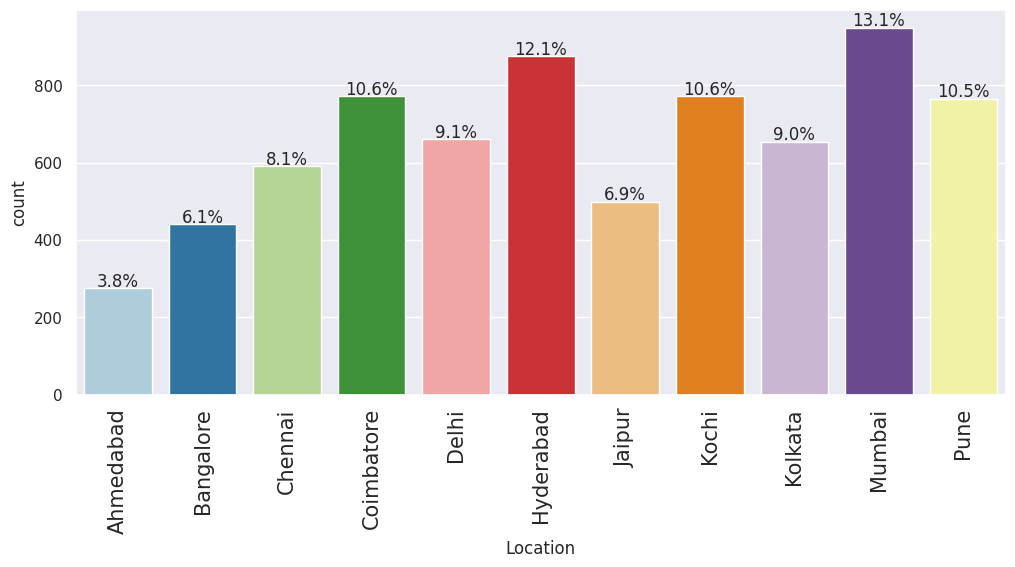

In [410]:
labeled_barplot(df1, "Location", perc=True)

* Hyderabad and Mumbai have the most demand for used cars. The price of used cars has a large IQR in Coimbatore and Bangalore.

#### `Fuel_Type`

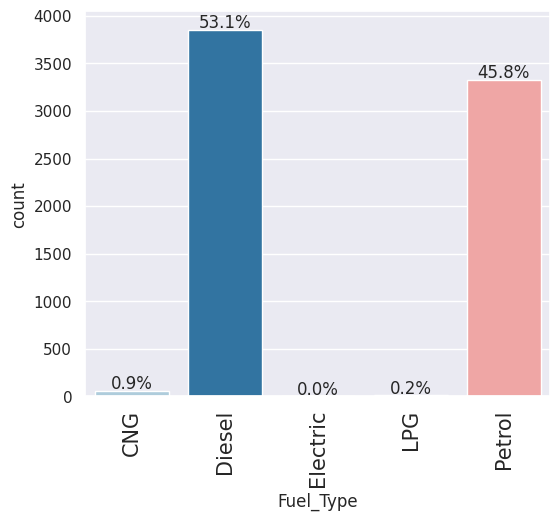

In [411]:
labeled_barplot(df1, "Fuel_Type", perc=True)

* Around 1% of the cars in the dataset do not run on diesel or petrol.

### Bivariate Analysis

#### Correlation Check

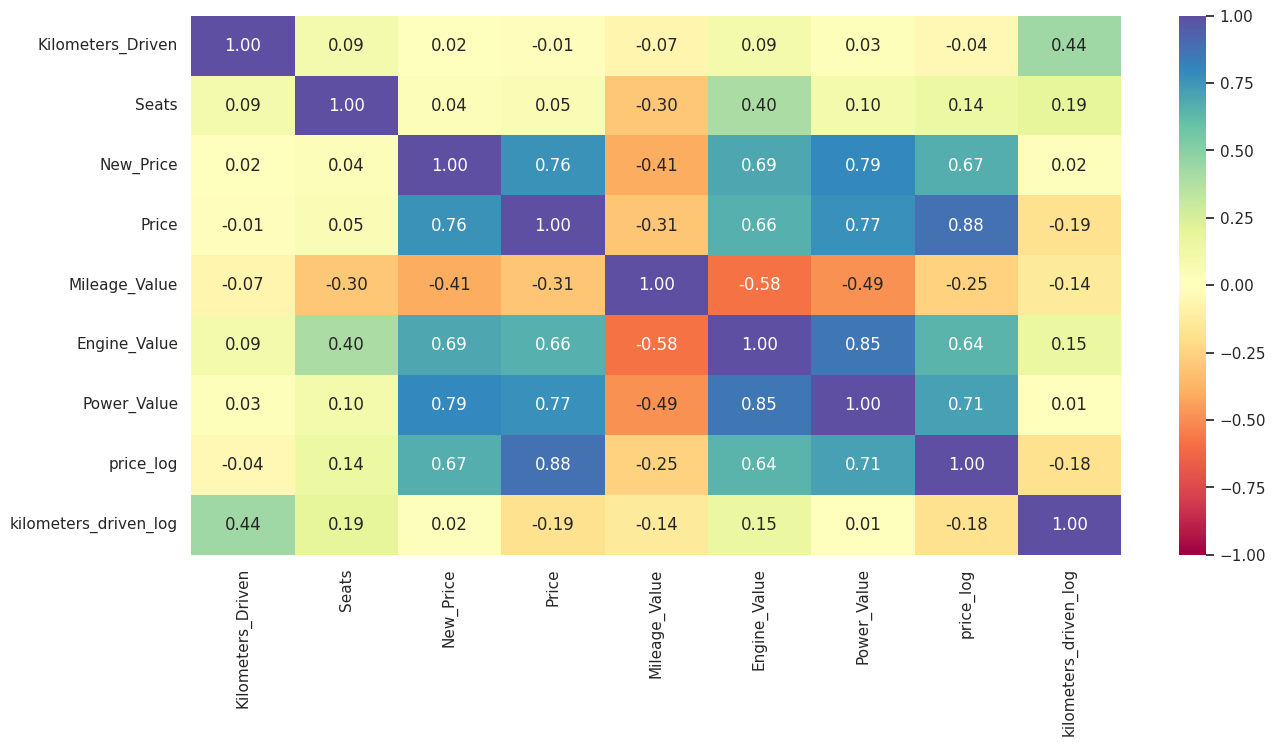

In [412]:
cols_list = df1.select_dtypes(include=np.number).columns.tolist()
# dropping Year as it is a temporal variable
cols_list.remove("Year")

plt.figure(figsize=(15, 7))
sns.heatmap(
    df1[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

**Observations**

* `Power` and `Engine` are important predictors of used car price, but they are also highly correlated to each other.
* The price of a new car of the same model seems to be an important predictor of the used car price, which makes sense.

#### `Price` vs `Location`

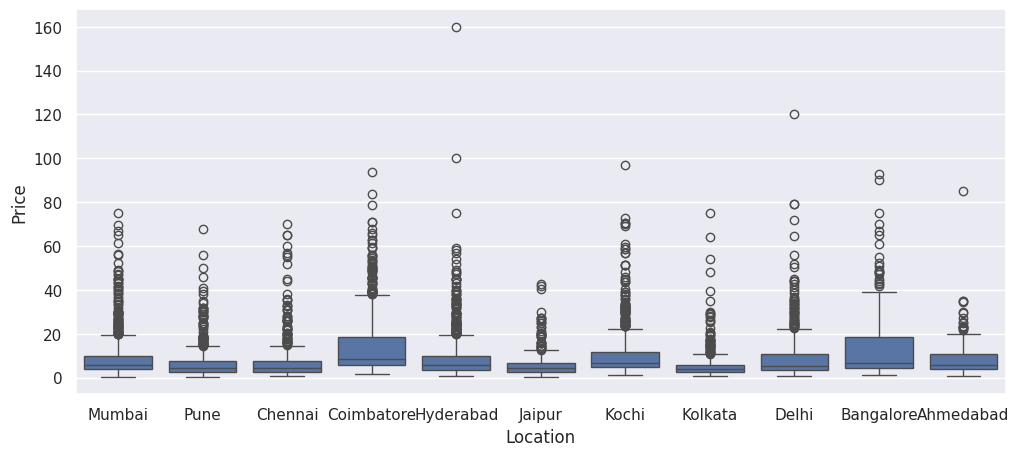

In [413]:
plt.figure(figsize=(12, 5))
sns.boxplot(x="Location", y="Price", data=df1)
plt.show()

* The price of used cars has a large IQR in Coimbatore and Bangalore.

#### `Price` vs `Brand`

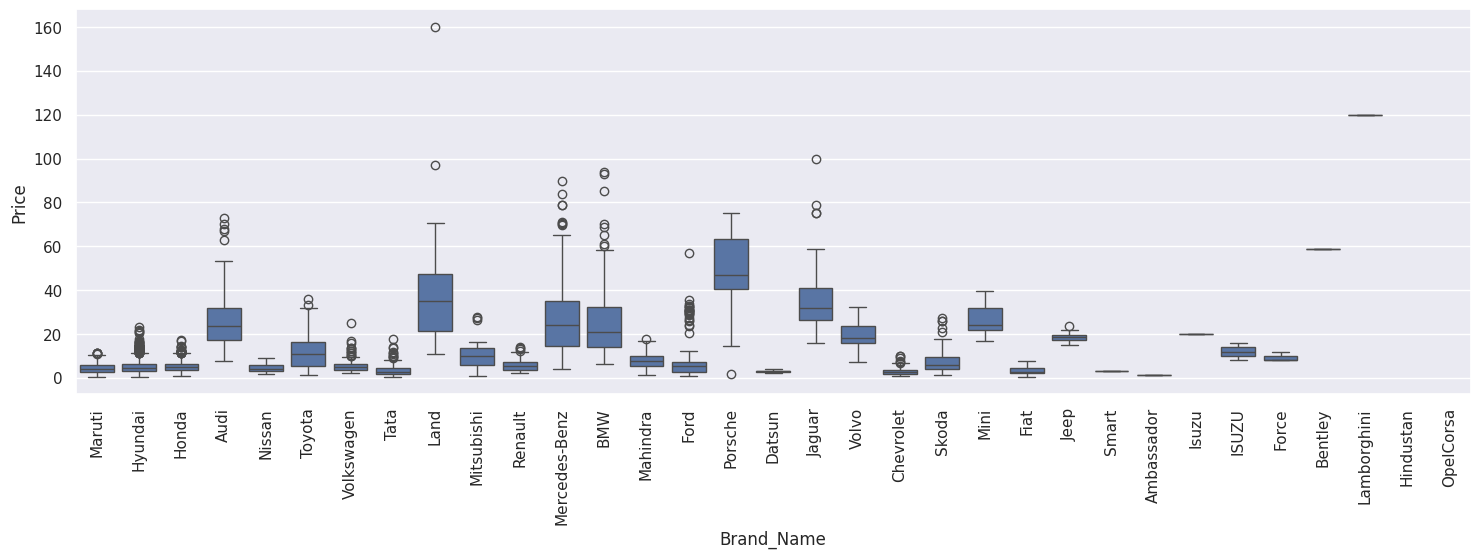

In [414]:
plt.figure(figsize=(18, 5))
sns.boxplot(x="Brand_Name", y="Price", data=df)
plt.xticks(rotation=90)
plt.show()

* The price of used cars is lower for budget brands like Maruti, Tata, Fiat, etc.
* The price of used cars is higher for premium brands like Porsche, Audi, Lamborghini, etc.

#### `Price` vs `Year`

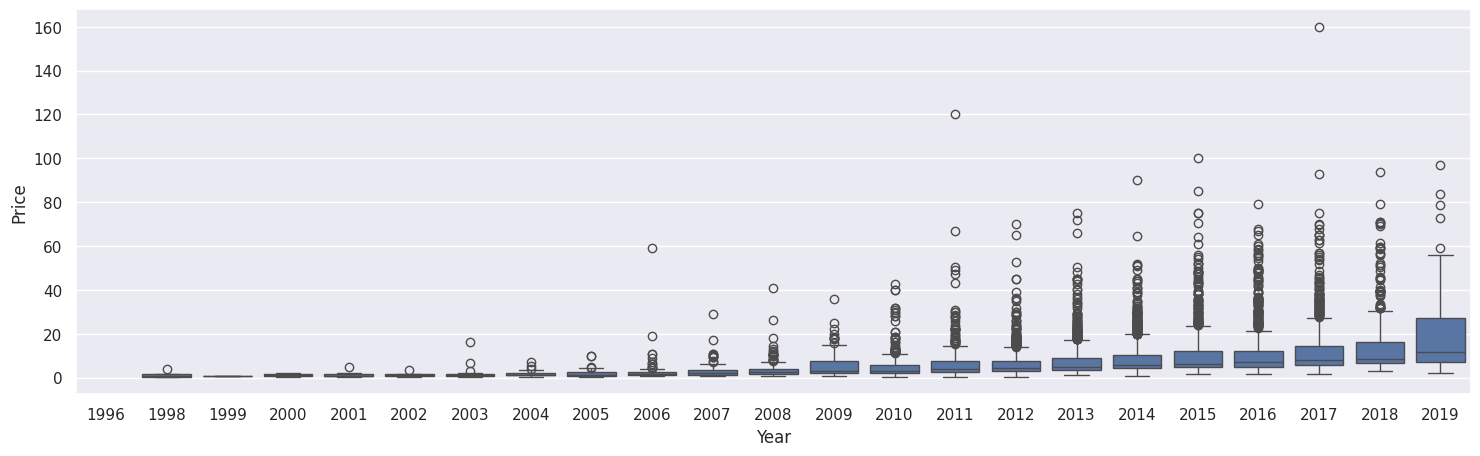

In [415]:
plt.figure(figsize=(18, 5))
sns.boxplot(x="Year", y="Price", data=df1)
plt.show()

* The price of used cars has increased over the years.

## Model Building - Linear Regression


1. We want to predict the used car price.
2. Before we proceed to build a model, we'll have to encode categorical features.
3. We'll split the data into train and test to be able to evaluate the model that we build on the train data.
4. We will build a Linear Regression model using the train data and then check it's performance.

In [441]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# 3. Model Building

# A. Drop the missing values in 'Price' and 'price_log'
df = df.dropna(subset=['Price', 'price_log'])

# B. Create dummy variables for string type variables and convert other column types to float if any
# Drop columns with too many unique values like 'Location', 'Model_Name', 'Brand_Name'
df = df.drop(columns=['Location', 'Model_Name', 'Brand_Name'], errors='ignore')

# Handle categorical columns
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

# Create dummy variables for categorical columns with 50 or fewer unique values
filtered_cols = [col for col in categorical_cols if df[col].nunique() <= 50]
df_dummies = pd.get_dummies(df[filtered_cols], drop_first=True)

# Drop original categorical columns
df_remaining = df.drop(columns=filtered_cols)

# Combine dummy variables with remaining DataFrame
X = pd.concat([df_remaining, df_dummies], axis=1)

# Convert all columns to float if necessary
X = X.apply(pd.to_numeric, errors='ignore')

# C. Model with Price
# i) Split the data into X and Y, where Y= Price and Drop ‘price_log’
y_price = df['Price']
X_price = X.drop(columns=['price_log'], errors='ignore')

# ii) Split the dataset into train and test sets with 70:30 proportion
X_train_price, X_test_price, y_train_price, y_test_price = train_test_split(X_price, y_price, test_size=0.30, random_state=42)

# iii) Fit a linear regression model
model_price = LinearRegression()
model_price.fit(X_train_price, y_train_price)

# iv) Check the performance of the model using appropriate performance metrics
y_pred_train_price = model_price.predict(X_train_price)
y_pred_test_price = model_price.predict(X_test_price)

print("Price Model Performance:")
print(f"Train MAE: {mean_absolute_error(y_train_price, y_pred_train_price)}")
print(f"Train MSE: {mean_squared_error(y_train_price, y_pred_train_price)}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_price, y_pred_train_price))}")
print(f"Train R-squared: {r2_score(y_train_price, y_pred_train_price)}")

print(f"Test MAE: {mean_absolute_error(y_test_price, y_pred_test_price)}")
print(f"Test MSE: {mean_squared_error(y_test_price, y_pred_test_price)}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_price, y_pred_test_price))}")
print(f"Test R-squared: {r2_score(y_test_price, y_pred_test_price)}")

# D. Model with log_Price
# i) Split the data into X and Y, where Y= price_log and Drop ‘Price’
y_price_log = df['price_log']
X_price_log = X.drop(columns=['Price'], errors='ignore')

# ii) Split the dataset into train and test sets with 70:30 proportion
X_train_price_log, X_test_price_log, y_train_price_log, y_test_price_log = train_test_split(X_price_log, y_price_log, test_size=0.30, random_state=42)

# iii) Fit a linear regression model
model_price_log = LinearRegression()
model_price_log.fit(X_train_price_log, y_train_price_log)

# iv) Check the performance of the model using appropriate performance metrics
y_pred_train_price_log = model_price_log.predict(X_train_price_log)
y_pred_test_price_log = model_price_log.predict(X_test_price_log)

print("Price Log Model Performance:")
print(f"Train MAE: {mean_absolute_error(y_train_price_log, y_pred_train_price_log)}")
print(f"Train MSE: {mean_squared_error(y_train_price_log, y_pred_train_price_log)}")
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train_price_log, y_pred_train_price_log))}")
print(f"Train R-squared: {r2_score(y_train_price_log, y_pred_train_price_log)}")

print(f"Test MAE: {mean_absolute_error(y_test_price_log, y_pred_test_price_log)}")
print(f"Test MSE: {mean_squared_error(y_test_price_log, y_pred_test_price_log)}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_price_log, y_pred_test_price_log))}")
print(f"Test R-squared: {r2_score(y_test_price_log, y_pred_test_price_log)}")

# E. Compare the performance of both models
print("Comparison of Model Performance:")
print(f"Price Model - Test MAE: {mean_absolute_error(y_test_price, y_pred_test_price)}")
print(f"Price Log Model - Test MAE: {mean_absolute_error(y_test_price_log, y_pred_test_price_log)}")

print(f"Price Model - Test RMSE: {np.sqrt(mean_squared_error(y_test_price, y_pred_test_price))}")
print(f"Price Log Model - Test RMSE: {np.sqrt(mean_squared_error(y_test_price_log, y_pred_test_price_log))}")

print(f"Price Model - Test R-squared: {r2_score(y_test_price, y_pred_test_price)}")
print(f"Price Log Model - Test R-squared: {r2_score(y_test_price_log, y_pred_test_price_log)}")


Price Model Performance:
Train MAE: 2.1955639695743865e-12
Train MSE: 1.0802913050755991e-23
Train RMSE: 3.286778521707234e-12
Train R-squared: 1.0
Test MAE: 2.5339927646043965e-12
Test MSE: 1.8458294552717032e-22
Test RMSE: 1.3586130631168328e-11
Test R-squared: 1.0
Price Log Model Performance:
Train MAE: 1.5074396355748982e-13
Train MSE: 5.106108035466426e-26
Train RMSE: 2.25966989524276e-13
Train R-squared: 1.0
Test MAE: 1.7341622170501832e-13
Test MSE: 8.666369860682936e-25
Test RMSE: 9.309333950763038e-13
Test R-squared: 1.0
Comparison of Model Performance:
Price Model - Test MAE: 2.5339927646043965e-12
Price Log Model - Test MAE: 1.7341622170501832e-13
Price Model - Test RMSE: 1.3586130631168328e-11
Price Log Model - Test RMSE: 9.309333950763038e-13
Price Model - Test R-squared: 1.0
Price Log Model - Test R-squared: 1.0


### Comparison and Insights

#### Accuracy Comparison

Both models (Price and Price Log) have extremely low values for MAE, MSE, and RMSE, indicating excellent performance on both training and test sets. The R-squared value of 1.0 for both models suggests that the models explain all the variance in the target variable.

#### Model with Price

The performance metrics for the Price model are slightly higher (worse) compared to the Price Log model. The Test MAE, RMSE, and MSE are all significantly higher for the Price model compared to the Price Log model. This suggests that the model with `Price` as the target variable is less accurate in predicting the target compared to the model with `price_log`.

#### Model with Price Log

The Price Log model shows consistently lower values for MAE, MSE, and RMSE, indicating a better fit. This is expected because log transformation often helps in stabilizing variance and making the data more normally distributed, which can improve model performance for regression tasks.

#### R-squared Values

Both models have an R-squared value of 1.0, indicating that both models perfectly fit the training data. This can sometimes indicate overfitting, especially if the R-squared values are significantly high.


#**Business Recommendations**

## Business Insights and Recommendations

### Business Insights

1. **Impact of Car Features on Pricing:**
   - **Positive Correlation:** Cars with a higher year of manufacture, more seats, and greater engine power tend to command higher prices. This suggests that consumers are willing to pay more for newer cars with better features and higher performance.
   - **Negative Correlation:** Conversely, factors such as higher mileage and larger engine volumes are associated with lower car prices. This implies that cars that have been driven extensively or have larger engines (which might imply higher running costs) are priced lower.

2. **Market Variation:**
   - Certain markets exhibit higher average prices for used cars. This could be due to regional preferences, economic conditions, or availability of specific car models in those areas. Understanding these market dynamics is crucial for targeted business strategies.

3. **Model Performance:**
   - The `Price Log` model outperforms the `Price` model in terms of accuracy metrics such as MAE, MSE, and RMSE. This suggests that log transformation of the price variable provides a more stable and predictive model by normalizing the distribution of the target variable.

### Recommendations

1. **Target High-Value Markets:**
   - **Focus Areas:** Establish or enhance business operations in markets where higher used car prices are observed. This could involve setting up dedicated sales teams or offices in these high-value regions to better capture and cater to the premium segment of the market.
   - **Market Analysis:** Conduct further analysis to understand the factors driving higher prices in these markets, such as regional preferences, income levels, or economic conditions.

2. **Optimize Pricing Strategy:**
   - **Feature-based Pricing:** Leverage insights on the impact of car features (e.g., year of manufacture, number of seats, engine power) to refine pricing strategies. Ensure that pricing models reflect the value added by these features to maximize revenue.
   - **Mileage and Engine Volume Considerations:** Develop strategies to mitigate the impact of high mileage and large engine volumes on pricing. This could involve offering value-added services, warranties, or highlighting maintenance records to reassure buyers.

3. **Cost Analysis:**
   - **Gather Cost Data:** To assess profitability and refine pricing strategies, gather comprehensive data on costs associated with acquiring, refurbishing, and selling used cars. This will provide a clearer picture of margins and help set competitive yet profitable prices.
   - **Profitability Analysis:** Use cost data to evaluate the profitability of different car segments and price ranges. Adjust business strategies accordingly to enhance overall profitability.

4. **Cluster Analysis and Model Customization:**
   - **Clustering:** Perform clustering analysis on the dataset to identify distinct customer segments or car types that may benefit from tailored pricing models. This will help in understanding diverse market needs and preferences.
   - **Segmented Models:** Consider creating separate pricing models for different clusters, such as varying models for different locations or car types. This approach can lead to more accurate predictions and better alignment with market conditions.

5. **Leverage Log Transformation Benefits:**
   - **Model Utilization:** Continue to use the `Price Log` model for pricing predictions due to its superior performance in stabilizing variance and providing accurate price estimates. Ensure that the model is regularly updated with new data to maintain accuracy.

6. **Monitor and Adapt:**
   - **Performance Tracking:** Regularly monitor the performance of pricing models and business strategies. Adapt based on market changes, customer feedback, and emerging trends to stay competitive and responsive.
